### Data Exploration Exercises

Class balance check
Prompt:
Check how many samples there are for each class in the Digits dataset. Plot a bar chart of counts. Are the classes balanced?

Compute the proportion of each class relative to the total number of samples

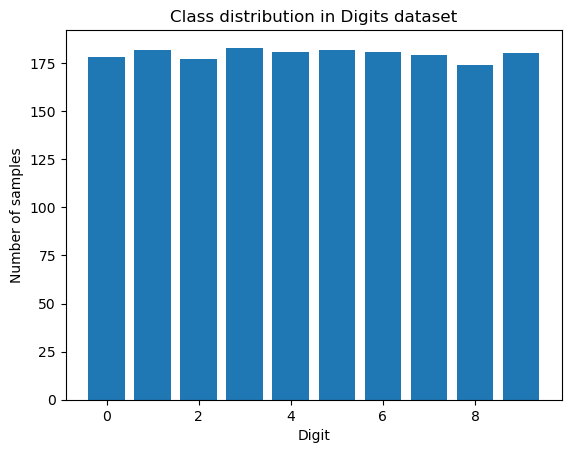

Class counts and proportions:
  Class 0: 178 samples (9.91%)
  Class 1: 182 samples (10.13%)
  Class 2: 177 samples (9.85%)
  Class 3: 183 samples (10.18%)
  Class 4: 181 samples (10.07%)
  Class 5: 182 samples (10.13%)
  Class 6: 181 samples (10.07%)
  Class 7: 179 samples (9.96%)
  Class 8: 174 samples (9.68%)
  Class 9: 180 samples (10.02%)


In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

# Count samples per class
labels, counts = np.unique(digits.target, return_counts=True)
proportions = counts / counts.sum()

# --- Bar plot ---
plt.bar(labels, counts)
plt.xlabel("Digit")
plt.ylabel("Number of samples")
plt.title("Class distribution in Digits dataset")
plt.show()

# --- Print counts and proportions ---
print("Class counts and proportions:")
for label, count, prop in zip(labels, counts, proportions):
    print(f"  Class {label}: {count} samples ({prop:.2%})")



#### Feature range / scaling awareness
Prompt:
Compute the min, max, and mean of each feature in California Housing. Which features might need scaling before ML?

In [33]:
from sklearn.datasets import fetch_california_housing
cal = fetch_california_housing(as_frame=True)

summary = cal.frame.describe().T[['min', 'max', 'mean']]
print(summary)


                    min           max         mean
MedInc         0.499900     15.000100     3.870671
HouseAge       1.000000     52.000000    28.639486
AveRooms       0.846154    141.909091     5.429000
AveBedrms      0.333333     34.066667     1.096675
Population     3.000000  35682.000000  1425.476744
AveOccup       0.692308   1243.333333     3.070655
Latitude      32.540000     41.950000    35.631861
Longitude   -124.350000   -114.310000  -119.569704
MedHouseVal    0.149990      5.000010     2.068558


#### Feature-based slicing 
Use California Housing: select all rows where a feature meets a condition.
Example:
Select all houses where MedInc > 8 (high-income blocks).
Compute average MedHouseVal in this subset.

In [34]:
high_income = cal.frame[cal.frame['MedInc'] > 8]
print("Number of high-income blocks:", len(high_income))
print("Average house value in high-income blocks:", high_income['MedHouseVal'].mean())



Number of high-income blocks: 690
Average house value in high-income blocks: 4.606393347826087


#### Distance / similarity between images
Prompt:
Pick two Olivetti Faces images. Compute the Euclidean distance between them. Which are “closer” or “farther” visually?


Euclidean distance between the images: 12.70


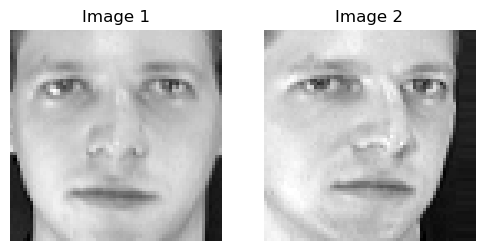

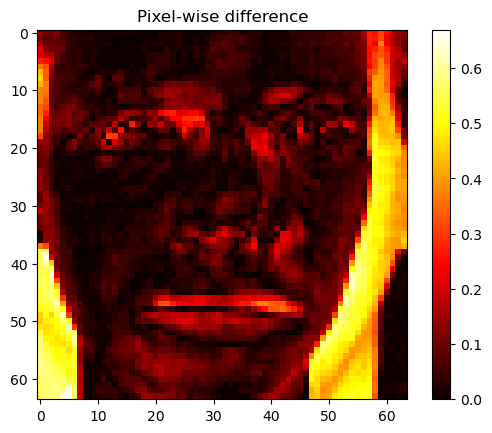

In [35]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from numpy.linalg import norm
import numpy as np

# Load dataset
olivetti = fetch_olivetti_faces()

# Select two images
img1 = olivetti.images[0]
img2 = olivetti.images[1]

# --- 1. Euclidean distance ---
dist = norm(img1.ravel() - img2.ravel())
print(f"Euclidean distance between the images: {dist:.2f}")

# --- 2. Plot images side by side ---
fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].imshow(img1, cmap='gray')
axes[0].set_title("Image 1")
axes[0].axis('off')
axes[1].imshow(img2, cmap='gray')
axes[1].set_title("Image 2")
axes[1].axis('off')
plt.show()

# --- 3. Plot absolute difference as heatmap ---
diff = np.abs(img1 - img2)
plt.imshow(diff, cmap='hot')
plt.title("Pixel-wise difference")
plt.colorbar()
plt.show()


Image subset slicing by metadata
Use Olivetti Faces: select all images of a specific person.

Plot first 4 images of that person

Number of images for person 8: 10


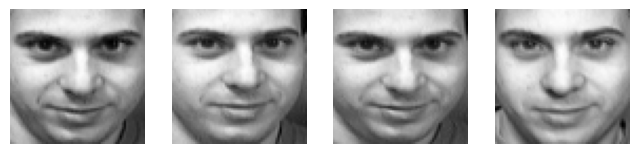

In [36]:
person_id = 8
person_images = olivetti.images[olivetti.target == person_id]
print(f"Number of images for person {person_id}:", person_images.shape[0])

# Plot first 4 images of this person
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,4, figsize=(8,2))
for i, ax in enumerate(axes):
    ax.imshow(person_images[i], cmap='gray')
    ax.axis('off')
plt.show()


#### Reshaping image data
Prompt:
Flatten the first Olivetti Faces image into a 1D array. Then reshape it back to the original image shape for plotting.

Plot original and reshaped image to show they are the same


Flattened shape: (4096,)
Reshaped shape: (64, 64)


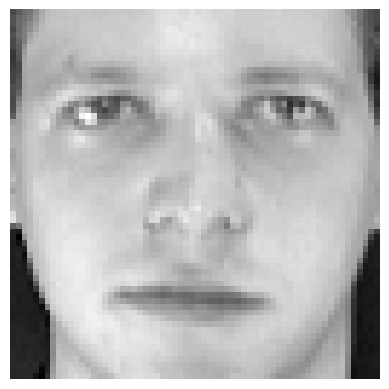

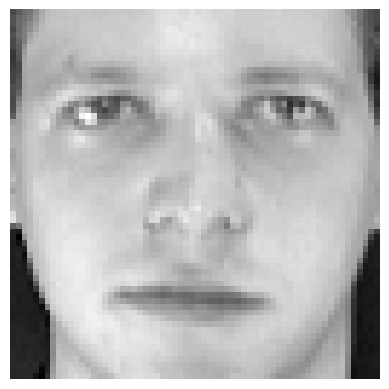

In [37]:
img = olivetti.images[0]
flattened = img.ravel()
print("Flattened shape:", flattened.shape)

# Reshape back
reshaped = flattened.reshape(img.shape)
print("Reshaped shape:", reshaped.shape)

# Plot to confirm
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


plt.imshow(reshaped, cmap='gray')
plt.axis('off')
plt.show()


#### BONUS: Train/Test Split and Stratification
Prompt:
Explore how the class distribution changes depending on how you split the data. Use the Digits dataset.
Split the dataset into train (80%) and test (20%) without stratification.
Count the number of samples per class in each split. Are the classes balanced?
Repeat the split with stratification using the target. Compare the class counts.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()
X = digits.data
y = digits.target

# --- 1. Split without stratification ---
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X, y, test_size=0.2, random_state=42
)

labels, counts_train_ns = np.unique(y_train_ns, return_counts=True)
_, counts_test_ns = np.unique(y_test_ns, return_counts=True)

print("Without stratification:")
print("Train class counts:")
for label, count in zip(labels, counts_train_ns):
    print(f"  Class {label}: {count}")
print("Test class counts:")
for label, count in zip(labels, counts_test_ns):
    print(f"  Class {label}: {count}")

# --- 2. Split with stratification ---
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

labels, counts_train_s = np.unique(y_train_s, return_counts=True)
_, counts_test_s = np.unique(y_test_s, return_counts=True)

print("\nWith stratification:")
print("Train class counts:")
for label, count in zip(labels, counts_train_s):
    print(f"  Class {label}: {count}")
print("Test class counts:")
for label, count in zip(labels, counts_test_s):
    print(f"  Class {label}: {count}")


Without stratification:
Train class counts:
  Class 0: 145
  Class 1: 154
  Class 2: 144
  Class 3: 149
  Class 4: 135
  Class 5: 135
  Class 6: 146
  Class 7: 145
  Class 8: 144
  Class 9: 140
Test class counts:
  Class 0: 33
  Class 1: 28
  Class 2: 33
  Class 3: 34
  Class 4: 46
  Class 5: 47
  Class 6: 35
  Class 7: 34
  Class 8: 30
  Class 9: 40

With stratification:
Train class counts:
  Class 0: 142
  Class 1: 146
  Class 2: 142
  Class 3: 146
  Class 4: 145
  Class 5: 145
  Class 6: 145
  Class 7: 143
  Class 8: 139
  Class 9: 144
Test class counts:
  Class 0: 36
  Class 1: 36
  Class 2: 35
  Class 3: 37
  Class 4: 36
  Class 5: 37
  Class 6: 36
  Class 7: 36
  Class 8: 35
  Class 9: 36
